# Classification

The purpose of this notebook is to get an introduction to classification using different algorithms, and learn how to evaluate them
so that they can be tuned to our purpose.

We will be using the MNIST dataset (a dataset of hand written digits) so that we can classify them appropriately.

In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml("mnist_784", as_frame=False)

In [3]:
print(f"The retrieved dataset is in the format of a {type(mnist)} and has the following attributes {dir(mnist)}")

The retrieved dataset is in the format of a <class 'sklearn.utils._bunch.Bunch'> and has the following attributes ['DESCR', 'categories', 'data', 'details', 'feature_names', 'frame', 'target', 'target_names', 'url']


In [4]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

We have 10 categories in this dataset i.e. the digits going from 0-9. Which is what we are expecting based on the description above.

In [5]:
mnist.categories

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}

The dataset itself has arrays of 784, representing 784 pixels that are used to raw the number. Hence if you will notice the arrays 
in the dataset are quite sparse looking. The demensions of the image itself as described in the description is 28x28, so when we want to display it we have to reshape it accordingly

In [6]:
mnist.data[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

The targets associated with the input arrays are the digits themselves in a string format.

In [7]:
mnist.target

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [8]:
data = mnist.data
targets = mnist.target

We know that each array represents pixels that display the image. So lets display the digit using matplot lib so that we can see
what we are dealing with.

In [9]:
import matplotlib.pyplot as plt

In [10]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.figure(figsize=(2, 2))
    plt.imshow(image, cmap="binary")
    plt.axis("off")

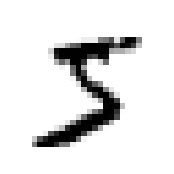

In [11]:
plot_digit(data[0])
plt.show()

Let's get a visual representation of all the classes that exist in the dataset.

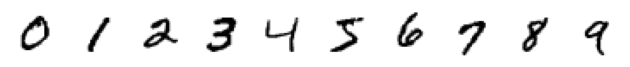

In [12]:
import matplotlib.pyplot as plt
import numpy as np

digits = 10 * [-1]
expected_classes_to_find = set(range(0, 10))

for i in range(len(targets)):
    target = int(targets[i])
    if target in expected_classes_to_find:
        digits[target] = data[i].reshape(28, 28)
        expected_classes_to_find.remove(target)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(1, 10)

# Iterate over the axes and images
for ax, img in zip(axes.flat, digits):
    ax.imshow(img, cmap='binary')
    ax.axis('off')  # Turn off axis labels and ticks

plt.tight_layout()
plt.show()

There look pretty decent so far. I'm sure there will be come odd ones in there, but we will get to that for sure.

## Training a Binary Classifier
We won't jump right into writing a classifier that will classify all the digits. That is a bigger task. As the book recommends, its probably best to understand a smaller problem first and see the classification from that perspective before we move to the bigger task.

We will write a classifier that classifies a digit into two classes: "is a 5" and "is not a 5"

In [13]:
y = targets
X = data

In [14]:
X_train, X_test, y_train, y_test = X[:6000], X[6000:], y[:6000], y[6000:]
y_5 = y_train == '5'

Above notice that we skipped two steps that would normally be quite important.
- Preprocessing the data
- Shuffling the dataset before splitting it into test and train sets.

Luckily for us MNIST dataset is already pre-shuffled and has been preprocessed so that it is easier to play with.

In [15]:
from sklearn.linear_model import SGDClassifier

In [16]:
def predict_and_draw(test_case):
    print(f"Is five? {sgd_classifier.predict([test_case])}")
    plot_digit(test_case)

In [17]:
sgd_classifier = SGDClassifier(random_state=42)
sgd_classifier.fit(X_train, y_5)

SGDClassifier(random_state=42)

Is five? [ True]


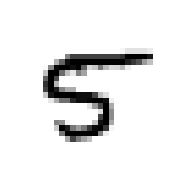

In [18]:
predict_and_draw(X_test[4])

Is five? [False]


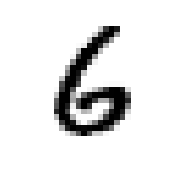

In [19]:
predict_and_draw(X_test[0])

That's pretty neat to start.

But the above are single cases, and as we can see. They are quite disinct. What about the cases that the model gets wrong? Let's see if we can find any of these. False positives, or false negatives.

In [20]:
import numpy as np

In [21]:
is_five = sgd_classifier.predict(X_train)
is_false_positive = np.logical_and(is_five, np.logical_not(y_5))
print([i for i in range(len(is_false_positive)) if is_false_positive[i]][:3])

[48, 469, 559]


In [22]:
is_false_negative = np.logical_and(np.logical_not(is_five), y_5)
print([i for i in range(len(is_false_negative)) if is_false_negative[i]][:3])

[132, 278, 635]


Is five? [ True]


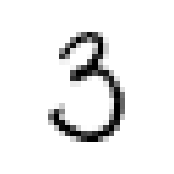

In [23]:
predict_and_draw(X_test[40])

Is five? [False]


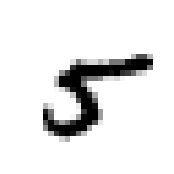

In [24]:
predict_and_draw(X_test[11])

Clearly we have some stark errors. So we need to evaluate our model to check its overall performance. 

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(sgd_classifier, X_train, y_5, cv=4, scoring="accuracy")
scores

array([0.95666667, 0.96066667, 0.96      , 0.96866667])

Amazing right? I thought so too when I got to this point in the book. But this is misleading, we can demonstrate the same using a dummy 
classifier.

In [26]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier()
dummy_classifier.fit(X_train, y_train)

cross_val_score(dummy_classifier, X_train, y_5, cv=4, scoring="accuracy")

array([0.914     , 0.914     , 0.91466667, 0.91466667])

Wow, so even with out dummy classifier our results are above 90%. This is because of the particular problem we are solving with our
binary classifier. Our dataset has a lot fewer '5's than the rest of the digits. So, the model is able to mark a lot of things as "not five" with the probably of being right more often than not. This is a common problem with skewed datasets.

There has to be a better way to quantify our errors and accuracy. Confusion Matrices to the rescue!

## Confusion Matrix

The confusion matrix is a matrix that groups the results of a model into 4 distinct categories.
- True Positive
- True Negative
- False Positive
- False Negative
Based on the occurrences of each of these classes, we can then calculate a few different measures to gauge the performance of our model.

In [27]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(sgd_classifier, X_train, y_5, cv=4)
confusion_matrix(y_5, predictions)

array([[5361,  125],
       [ 106,  408]])

Based on the above we can see that we have:
- 5361 True negatives (TN)
- 106 False negatives (FN)
- 408 True positives (TP)
- 125 False positives (FP)

So that means while actually identifying "5"s we still have a little more than 200 errors which is nearly half the total "5"s we have in this dataset.

### Precision and Recall

Using this we can calculate two different measures that can help us guide us in the classification task.
1) Precision - the accuracy of the positive predictions
2) Recall/Sensitivity - true positive rate.

Both the above measures in conjuction are used to tune a classification model.

Precision =  `TP / (TP + FP)`
Recall = `TP / (TP + FN)`

Which in our cause we can see below.

In [28]:
print(f"Precision: {408/ (408 + 125)}, Recall: {408/ (408 + 106)}")

Precision: 0.7654784240150094, Recall: 0.7937743190661478


We don't need to calculate this manually.

Based on the precision and recall scores, we can tell that our model is not performing the best. It is correct about the "5"s only 76% of the time, moreso, it only seems to detect like 79% of the "5"s are compared to the 91% and 95% accuracy it showed us during corss validation.

In [29]:
from sklearn.metrics import precision_score, recall_score

print(f"Precision: {precision_score(y_5, predictions)}, Recall: {recall_score(y_5, predictions)}")

Precision: 0.7654784240150094, Recall: 0.7937743190661478


Another metric for this is the F1 score - the `harmonic mean` of precision and recall. It is used to compare two classifiers using a
single score and is generally maximized when precision and recall are both high. However, that might not always be the requirement. 
Somethimes you might want a model with high precisions and lower recall so as to get only high quality results and reduce the false positives
or you might require a model that has high recall and lower precision.

In [30]:
from sklearn.metrics import f1_score

f1_score(y_5, predictions)

0.7793696275071633

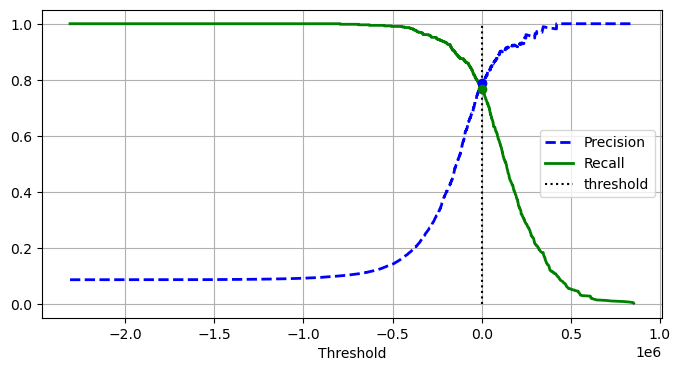

In [31]:
from sklearn.metrics import precision_recall_curve

threshold = 3000
y_scores = cross_val_predict(sgd_classifier, X_train, y_5, cv=3, method="decision_function")
precisions, recalls, thresholds = precision_recall_curve(y_5, y_scores)

plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# Took this from the collab notebook. Makes the graps much prettier.
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()

As precision increasing (blue line) recall decreases. So you cannot have a model with maximum precision and maximum recall.

The threshold mentioned above is the threshold specified by the model. When the models decision function evaluates the inputs, it spits
out a score. Depending on the models threshold, the score is then used to output either a True or a False for the classification problem
The more we increase this threshold of our function, the higher the precision will get - this is because the model is become more and
more discriminating - while the recall will go down.

In the last `cross_val_predict` call that we performed, we specified the method as `decision_function`. This makes our cros_val_predict function spit out our scores rather than the predictions of the model. We can then use these score in conjuction with out own threshold to play around and figure out at what precision and recall do we get the best results?

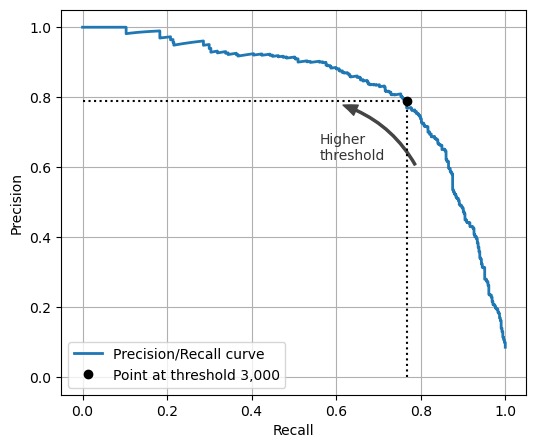

In [32]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# Took this from the collab notebook. Makes the graps much prettier.
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [33]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90th_precision = thresholds[idx_for_90_precision]
threshold_for_90th_precision

105660.23702487332

### ROC Curve

The receiver operating charactersitic curve is another way to evaluate a model.

Odd name for a model evaluation function on? Well, the ROC curve was developed by electrical 
engineers during World War 2 to evaluate radar receivers - hence the 'Receiver' operating characteristic
it was then used increasing in psychology to account for perceptual detection of stimuli. Kinda cool how
things make their way through history to reach us.

The ROC curve is plot of the 'true positive rate' (Recall) against the `false positive rate`.
Here the false positive rate is 1 - `true negative rate` (Specificity).

- TPR (Recall) - the number of times a prediction is correctly predicted as positive
- FPR (Fall-out) - the number of times a prediction is wrongly predicted as positive.
- TNR (Specificity) - the number of times a prediction is correctly predicted as negative

Formulae </br>
`FPR = FP / (FP + TN) = FP / N = 1 - TNR` </br>
`TNR = TN / (TN + FP) = TN / N` </br>
Where 'N' is the number of all negatives in the data set.

In [34]:
from sklearn.metrics import roc_curve

In [35]:
fpr, tpr, thresholds = roc_curve(y_5, y_scores)

In [36]:
print("Just so we have a sense of what we are looking at here with the outputs")
print(f"False postive rates: {fpr[:3]}")
print(f"True postive rates: {tpr[:3]}")
print(f"Thresholds: {thresholds[:3]}")

Just so we have a sense of what we are looking at here with the outputs
False postive rates: [0. 0. 0.]
True postive rates: [0.         0.00194553 0.10311284]
Thresholds: [            inf 852681.43917402 420208.22474012]


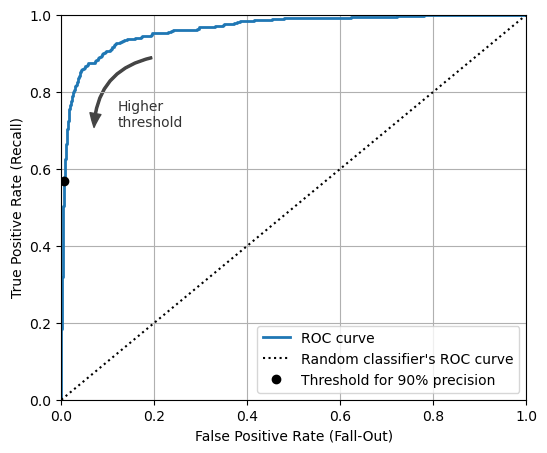

In [37]:
import matplotlib.patches as patches 

idx_for_threshold_at_90 = (thresholds <= threshold_for_90th_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5)) 
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# Took this from the collab notebook. Makes the graps much prettier.
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=10)

plt.show()

As we can see in the above graph. The trade off is clear. As the recall of the model increases so does the fall-out rate. Our goal is to maximize recall while keeping the fall out rate as low as possible.

The dotted line represents a random classifier, where recall increases linearly with fall out. An ideal classifier will stay as far away from this line as possible while staying to the top of the grap i.e. high recall and low fall-out.

Let's try this with a different classifier.

**Important:** When in doubt of whether to use the ROC curve or the PR curve to evaluate your classifications, the rule of thumb is we should use the PR curve if the target class is rare in the data set. This is because the PR curve allows us to evaluate the precision as well as the recall.

In [38]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
# we use the function 'predict_proba' cause the model doesn't really work with a decision function.
# we dont' go too much into this now. It is covered more later.
y_forest_prob = cross_val_predict(forest_clf, X_train, y_5, cv=3, method="predict_proba")
y_forest_prob

array([[0.37, 0.63],
       [0.98, 0.02],
       [0.95, 0.05],
       ...,
       [0.66, 0.34],
       [0.99, 0.01],
       [0.9 , 0.1 ]])

The returned values are a probability of an entry being positive or negative case. If we take the first
one as an example, It has a 37% chance of not being a 5, and a 63% change of being a 5. Both add up to 100. We will use the positive column as the score.

In [39]:
y_forest_scores = y_forest_prob[:, 1]
precisions_forest, recalls_forest, forest_thresholds = precision_recall_curve(y_5, y_forest_scores)

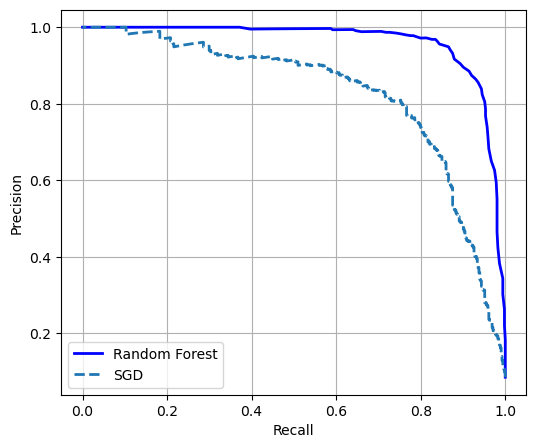

In [40]:
plt.figure(figsize=(6, 5))  # Took this from the collab notebook and made some edits
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend(loc="lower left")

plt.show()

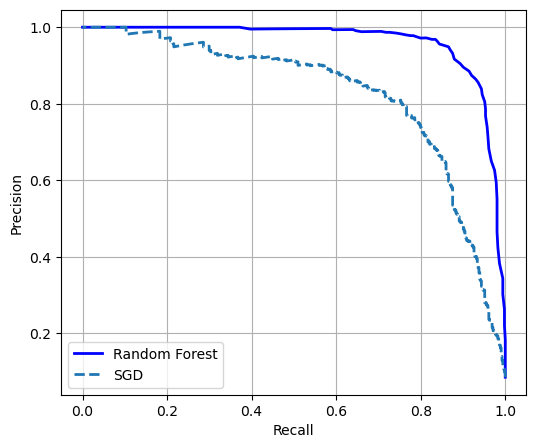

In [41]:
y_forest_scores = y_forest_prob[:, 1]
precisions_forest, recalls_forest, forest_thresholds = precision_recall_curve(y_5, y_forest_scores)
plt.figure(figsize=(6, 5))  # Took this from the collab notebook and made some edits
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend(loc="lower left")

plt.show()

We can see that the Random Forest model does much better than the SGD classifier with the precision and recall curve.
Let's check with the ROC curve.

In [42]:
forest_fpr, forest_tpr, forest_thresholds = roc_curve(y_5, y_forest_scores)

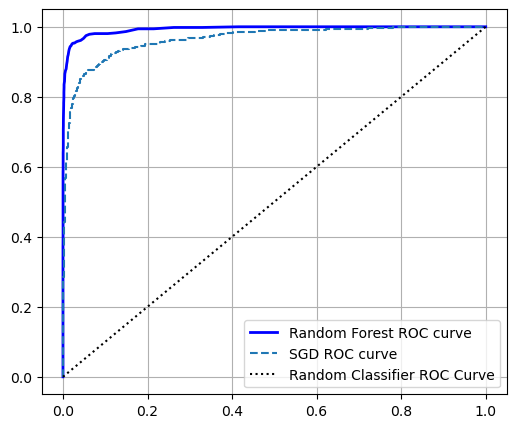

In [43]:
plt.figure(figsize=(6, 5)) 
plt.plot(forest_fpr, forest_tpr, "b-", linewidth=2, label="Random Forest ROC curve")
plt.plot(fpr, tpr, "--", label="SGD ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random Classifier ROC Curve")

plt.legend(loc="lower right")
plt.grid()

We can see that the ROC curve for this is much better as well.

In [44]:
from sklearn.metrics import roc_auc_score

# You can play around with the threshold to adjust the scores below.
threshold = 0.38
forest_predictions = (y_forest_scores >= threshold)
print(f"Precision: {precision_score(y_5, forest_predictions)}")
print(f"Recall: {recall_score(y_5, forest_predictions)}")
print(f"F1 score: {f1_score(y_5, forest_predictions)}")
# a perfect model will have this value as 1 and a random one will have it at 0.5
print(f"ROC Area Under the Curve: {roc_auc_score(y_5, y_forest_scores)}")

Precision: 0.9681093394077449
Recall: 0.8268482490272373
F1 score: 0.8919202518363064
ROC Area Under the Curve: 0.9936124993084626


## Multiclass Classification

Multiclass or multinomial classifiers are simply classifiers that can distinguish between more than
a single class.

Some classifiers can handle multiple classes natively (e.g. LogisticRegression or RandomForrestClassifier) but we
can also accomplish the same using binary classifiers (e.g. SVC)

**One-versus-the-rest/One-versus-all (OvR/OvA)**: You train a binary classifier for each class and 
when you want to make a prediction you run the input through all the classifiers and select the
one with the highest score. In the case of MNIST, we would have 10 classifiers (one for each digit)

**One-versus-One (OvO)**: If there are N classes, you end up training `N x (N-1) /2` classes. This is
because you train a classifier to diffrentiate between two classes. In the case of MNIST:
0 and 1s, 0 and 2s ... 8 and 9s etc. To make a prediction here you have to run the input through all the
classifiers trained and see which class "wins the most duels".

The main advantage with this stratergy is that each classifier only needs to be trained on a smaller
    subset of the entire dataset (good for algos like SVM).

In [45]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

print(f"Predicted: {svm_clf.predict([X_train[2300]])}, Actual: {y_train[2300]}")

Predicted: ['6'], Actual: 6


As you can see above, we do get the correct prediction. If you see the score below however you
will notice that we have multiple scores as outputs for the decision function. This is the
model using OvR underneath and spitting out a score for each classifier.

6 has the highest score and is the output as expected.

In [46]:
scores = svm_clf.decision_function([X_train[2300]])
scores

array([[-0.27760767,  0.72038827,  6.15966667,  1.72451173,  8.27473851,
         4.02783001,  9.30543462,  2.73846472,  5.14194876,  7.18200674]])

In [47]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [48]:
svm_clf.classes_[scores.argmax()]

'6'

Depending on your inputs, Scikit automatically chooses if it should run OvR or OvO. However, you
can make it use a certain stratergy over the other. You can check the documentation or use the `help` function on the model to see what startergy parameters it accepts e.g. `help(SVC)` shows us that it uses OvR by default.

In [49]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

ovr_clf.predict([X[1500]])

array(['9'], dtype='<U1')

In [50]:
# As mentioned, earlier, it has 10 estimators, one for each class.
len(ovr_clf.estimators_)

10

In [51]:
from sklearn.multiclass import OneVsOneClassifier

ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train[:2000], y_train[:2000])

ovo_clf.predict([X[1500]])

array(['9'], dtype=object)

In [52]:
# Using One versus One we get 45 estimators N x (N -1)/2
len(ovo_clf.estimators_)

45

## Error Analysis

Now that we are dealing with multiple classes in the output, our Confusion Matrix becomes a
lot more complex. Let's see below:

In [53]:
%%time
predictions = cross_val_predict(sgd_classifier, X_train, y_train, cv=3)
confusion_matrix(y_train, predictions)

CPU times: user 5.87 s, sys: 4.12 s, total: 9.99 s
Wall time: 5.14 s


array([[563,   0,   5,   2,   1,   3,  10,   1,   5,   2],
       [  0, 639,   9,   5,   1,   6,   2,   2,   6,   1],
       [  6,   7, 490,  16,   7,   5,  16,  13,  17,   4],
       [  3,   5,  25, 511,   4,  36,   2,   8,   8,   6],
       [  0,   3,  14,   3, 531,   3,  18,   5,  14,  32],
       [  5,   2,  10,  43,  13, 387,  17,   1,  26,  10],
       [  4,   2,  13,   2,   4,   8, 571,   0,   4,   0],
       [  5,   5,  10,   9,   6,   3,   2, 576,   1,  34],
       [  4,  12,  15,  31,   7,  34,  18,   3, 411,  16],
       [  8,   6,   4,   8,  12,   8,   0,  33,  18, 504]])

That's quite a big confusion matrix. As a human, it is quite hard to evaluate that. Scikit however,
does have some nice Confusion Matrix display tools that can assist us in better understandin the above.

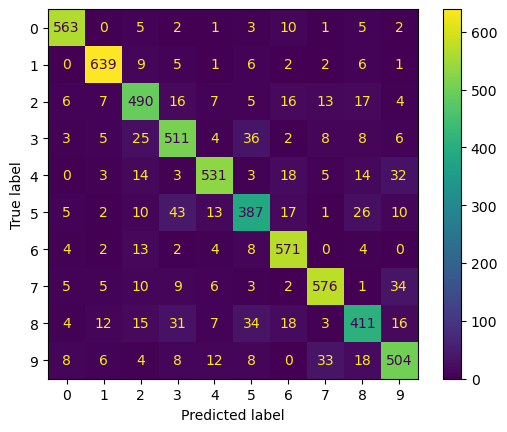

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, predictions)
plt.show()

This is a much better visual representation! We can still do better though. Let's try to visualize the above numbers as percentages rather than raw counts.

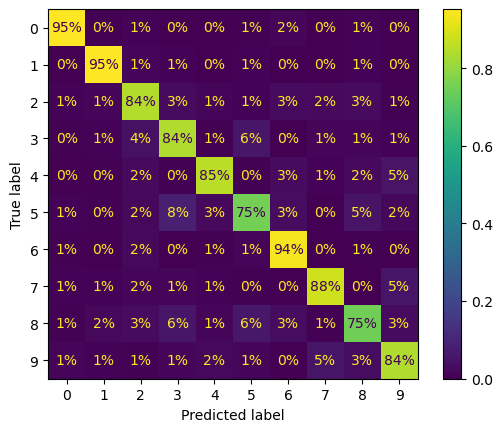

In [55]:
ConfusionMatrixDisplay.from_predictions(y_train, predictions, 
                                        normalize="true", values_format=".0%")
plt.show()

In the above Confusion Matrix we are looking at the distribution of predictions. We can see that model seems to have a lot of problems with 8, with only 75% of them being
classified correctly (and 12% getting confused with the numbers 3 and 5) and it does really well with 0 and 1.

Let's see what the distribution of errors look like across the Confusion Matrix. We can do this by only giving weight to the predictions that don't match the actual class (i.e. the errors)

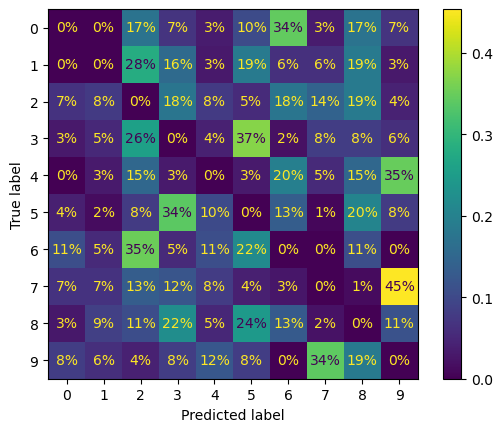

In [56]:
sample_weight = (predictions != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, predictions,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

In the above Confusion Matrix we are seeing the error distribution across the label (notice that the diagonal is consistently 0% - this is because there can be no errors at the intersection of the actual and predict label)
It is important understand that the number, say for example 45% for True 7 and Predicted 9, does not mean that 45% of the 7s were classified as 9s. Instead what it means is: of all the errors associated with the class 7, 45% of the errors were 9s.

*NOTE:* The Confusion Matrix above is normalized by row, if you want to normalize by column you can set the `normalize` param to `pred` (indicating normalize by the predicted lable or the column)

Since we are learning here we skipped a lot of the data exploration and preprocessing in this MNIST project we are doing. But once we have a good grasp of our error distributions, we shoudl take a look at the data to see if there is some further preprocessing we can do to improve our results.

## Multilabel Classification

Multilabel classification is when our model must output multiple classes as an ouput. Few examples of these:
 - Face recognition in pictures (we could recognize multiple faces)
 - Feature recognition (multiple features)

In [57]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

def is_single_digit_prime(number):
    primes = {'2', '3', '5', '7'}
    return number in primes

    
# y_train_large = (y_train >= 7) don't want to use the example example from the book
vec_fun = np.vectorize(is_single_digit_prime)
y_train_prime = vec_fun(y_train)
y_train_odd = (y_train.astype("int8") % 3 == 0)
y_multilabel = np.c_[y_train_prime, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [58]:
prediction = knn_clf.predict([X_train[3000]])
print(f"The models prediction for the number {y_train[3000]}. Prime: {prediction[0][0]}, Odd: {prediction[0][1]}") 

The models prediction for the number 9. Prime: False, Odd: True


In [59]:
y_train[3000]

'9'

As can be seen above, out model now returns two labels. One indicating whether the number is Prime and the
other is if the number is Odd. How do we analyze this model now?

We can perform cross validation and then compute the different score for the model.

In [60]:
predictions = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [61]:
print(f'Precision: {precision_score(y_multilabel, predictions, average="macro")}, Recall: {recall_score(y_multilabel, predictions, average="macro")}')

Precision: 0.954371623006542, Recall: 0.9501014497813883


In [62]:
print(f'F1 Score: {f1_score(y_multilabel, predictions, average="macro")}')

F1 Score: 0.9520577357435496


In [63]:
print(f'ROC Area under the Curve Score: {roc_auc_score(y_multilabel, predictions, average="macro")}')

ROC Area under the Curve Score: 0.9598809397891885


Notice that for each of the scores we provide the `average` argument to the calculation functions. We are computing the
scores for each of the labels and then just averaging them out to give us the score.

## Multioutput Classification

In the multioutput classification or multioutput-multiclass classification each label in the output can be
multiple classes. For example a model that outputs the pixels out an image as an output. The image will have
multiple pixels, but each pixel can also have a different value.

In [64]:
np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

The book constructs an example dataset for us above. What we are essentially doing is adding noise to the
MNIST data set, until our nice clean images look like the image below.

What we are then going to do is train the model by providing the noise images as inputs and expecting the clean
images as outputs. You can see immediately that the output here is not the number 6. But the clean pixels that allow us to 
draw the number 6.

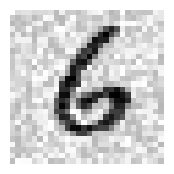

In [65]:
plot_digit(X_test_mod[0])

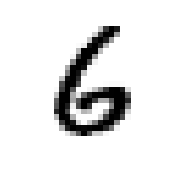

In [66]:
plot_digit(y_test_mod[0])

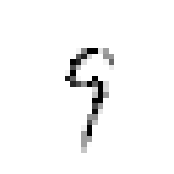

In [67]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_train_mod[1500]])
plot_digit(clean_digit)

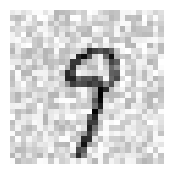

In [68]:
plot_digit(X_train_mod[1500])

Not too bad. It did a good job cleaning up the noise.

If you look below at the output of the model you will see that the output isn't a single class or a bunch of them,
but a number of different pixels, each having values that range from 0 - 255. This makes it a multioutput classifier.

In [69]:
clean_digit

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0